# Packages

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy.optimize import curve_fit

import joblib

from sklearn.linear_model import SGDClassifier

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

import warnings


from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score

from sklearn.model_selection import learning_curve

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

# Analysis and organization

In [131]:
# Carregar o arquivo
df = pd.read_csv('/home/jefferson/Documentos/MEUS TRABALHOS/artigo 4/scripts/data/dados_quantum_walk_T_100_50.csv')

# Visualizar as primeiras linhas
df.head()

,delta_theta,IPR,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.000000,16.049482,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,...,0.000140,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.010686,16.109290,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,...,0.000146,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0
2,0.021371,17.274234,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,...,0.000119,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0
3,0.032057,17.394967,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,...,0.000170,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0
4,0.042743,21.982325,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,...,0.000141,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0


In [132]:
# Seleciona as colunas e mantém como um DataFrame, mas colocando values ele cria uma nova matriz
df_probs = df.filter(like='prob_')
df_probs.head()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202
0,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,0.0,0.000140,...,0.000140,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0
1,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,0.0,0.000146,...,0.000146,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0
2,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,0.0,0.000119,...,0.000119,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0
3,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,0.0,0.000170,...,0.000170,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0
4,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,0.0,0.000141,...,0.000141,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0


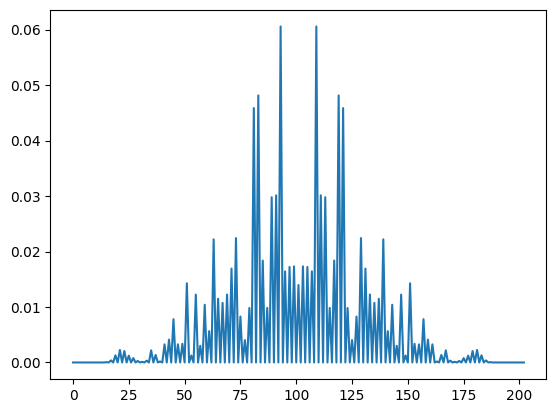

In [133]:
plt.plot(df_probs.iloc[25].values)
plt.show()

List of IPR

/tmp/ipykernel_8522/871869996.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


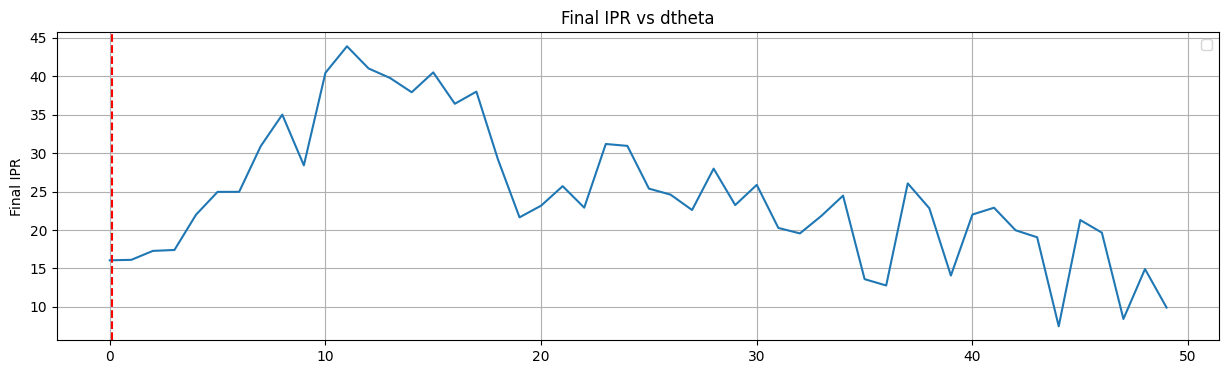

In [134]:
IPR_list = df['IPR'].values

plt.figure(figsize=(15,4))
plt.plot(df['IPR'].values)
plt.axvline(x=df['delta_theta'].iloc[np.argmax(IPR_list)], color='red', linestyle='--')
plt.title('Final IPR vs dtheta')
plt.ylabel('Final IPR')
#plt.xlim(0, 7500)
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_8522/1242234293.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


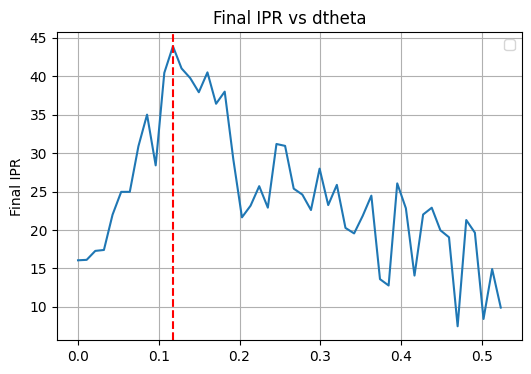

In [135]:
IPR_list = df['IPR']

plt.figure(figsize=(6,4))
plt.plot(df['delta_theta'].values[:2500],df['IPR'].values[:2500])
plt.axvline(x=df['delta_theta'].iloc[np.argmax(IPR_list)], color='red', linestyle='--')
plt.title('Final IPR vs dtheta')
plt.ylabel('Final IPR')
plt.legend()
plt.grid(True)
plt.show()

In [136]:
df.iloc[np.argmax(IPR_list)]
critical_exp = df['delta_theta'].iloc[np.argmax(IPR_list)]
critical_exp

np.float64(0.1175425822771691)

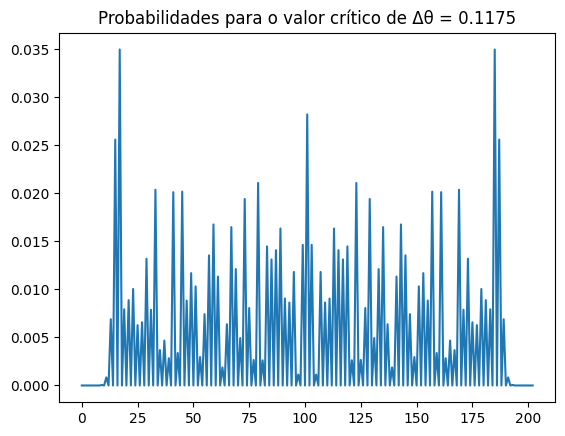

In [137]:
plt.plot(df_probs.iloc[np.argmax(IPR_list)].values)
plt.title(f'Probabilidades para o valor crítico de Δθ = {critical_exp:.4f}')
plt.show()

Data separation for training: Label 0 is assigned to delocalized states (ranging from $0$ to $50$), and Label 1 to localized states (ranging from $200$ to $250$).

In [138]:
# Assigning labels to the training data

n_total = len(df)
ponto_de_corte = np.argmax(df['IPR'].values)  # Onde os 0s terminam e os 1s começam

# Cria a coluna: metade 0, metade 1
coluna_rotulo = np.concatenate([
    np.zeros(ponto_de_corte), 
    np.ones(n_total - ponto_de_corte)
])

# Adiciona a coluna ao DataFrame e garanto que seja inteira
df_probs['label'] = coluna_rotulo.astype(int)

/tmp/ipykernel_8522/2789398605.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_probs['label'] = coluna_rotulo.astype(int)


Pego os 50 primeiros deslocalizados e depois mais 50 localizados

In [139]:
df_training = df_probs.iloc[np.r_[0:8, 42:50]]

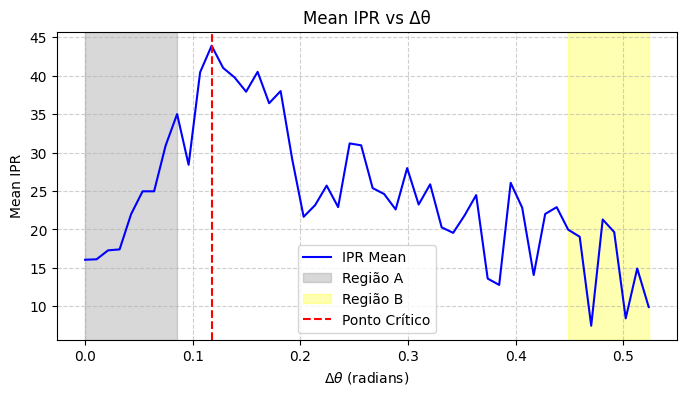

In [140]:
plt.figure(figsize=(8, 4))
plt.plot(df['delta_theta'].values,df['IPR'].values, label='IPR Mean', color='blue', zorder=2)

# Colorindo o primeiro intervalo [0:300]
plt.axvspan(df['delta_theta'].values[:][0], df['delta_theta'].values[:][8], 
            color='gray', alpha=0.3, label='Região A')

# Colorindo o segundo intervalo [700:1000]
# Nota: se o índice for 1000, use 999 para não estourar o limite do array
plt.axvspan(df['delta_theta'].values[:][42], df['delta_theta'].values[:][49], 
            color='yellow', alpha=0.3, label='Região B')

plt.title('Mean IPR vs Δθ')
plt.xlabel(r'$\Delta\theta$ (radians)')
plt.ylabel('Mean IPR')
plt.axvline(x=critical_exp, color='red', linestyle='--', label='Ponto Crítico')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

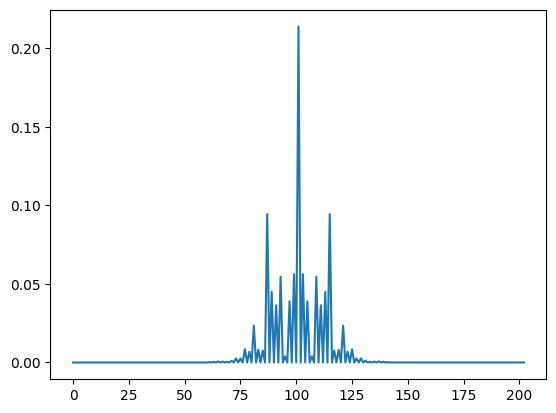

In [141]:
plt.plot(df_probs.iloc[49].values[:-1])
plt.show()

In [142]:
len(df_training.values[0])

204

Spliting 80% for training data and 20% for testing model's accuracy. Choice made radomly.

In [143]:
# 1. Definimos o Seed para reprodutibilidade
seed = 42

# 2. Criamos o set de Treino (80%)
df_train = df_training.sample(frac=0.8, random_state=seed)

# 3. Criamos o set de Teste (o que sobrou)
# O .drop() remove as linhas que já foram para o treino
df_test = df_training.drop(df_train.index)

In [144]:
df_train.head()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202,label
0,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,4.000856e-06,0.0,1.397188e-04,...,0.0,4.000856e-06,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0,0
1,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,4.209793e-06,0.0,1.458290e-04,...,0.0,4.209793e-06,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0,0
5,0.0,5.365476e-13,0.0,5.196309e-10,0.0,1.032697e-07,0.0,7.293757e-06,0.0,2.236475e-04,...,0.0,7.293757e-06,0.0,1.032697e-07,0.0,5.196309e-10,0.0,5.365476e-13,0.0,0
48,0.0,4.257465e-32,0.0,2.594491e-28,0.0,3.219640e-25,0.0,1.413168e-22,0.0,2.689253e-20,...,0.0,1.413168e-22,0.0,3.219640e-25,0.0,2.594491e-28,0.0,4.257465e-32,0.0,1
47,0.0,3.842752e-30,0.0,1.734951e-26,0.0,1.615047e-23,0.0,5.402049e-21,0.0,8.005230e-19,...,0.0,5.402049e-21,0.0,1.615047e-23,0.0,1.734951e-26,0.0,3.842752e-30,0.0,1


In [145]:
# Remove as duas
df_train = df_train.drop(columns=[df_train.columns[0], df_train.columns[-2]])
df_train.head()

,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,prob_10,...,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,label
0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,4.000856e-06,0.0,1.397188e-04,0.0,...,1.397188e-04,0.0,4.000856e-06,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0
1,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,4.209793e-06,0.0,1.458290e-04,0.0,...,1.458290e-04,0.0,4.209793e-06,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0
5,5.365476e-13,0.0,5.196309e-10,0.0,1.032697e-07,0.0,7.293757e-06,0.0,2.236475e-04,0.0,...,2.236475e-04,0.0,7.293757e-06,0.0,1.032697e-07,0.0,5.196309e-10,0.0,5.365476e-13,0
48,4.257465e-32,0.0,2.594491e-28,0.0,3.219640e-25,0.0,1.413168e-22,0.0,2.689253e-20,0.0,...,2.689253e-20,0.0,1.413168e-22,0.0,3.219640e-25,0.0,2.594491e-28,0.0,4.257465e-32,1
47,3.842752e-30,0.0,1.734951e-26,0.0,1.615047e-23,0.0,5.402049e-21,0.0,8.005230e-19,0.0,...,8.005230e-19,0.0,5.402049e-21,0.0,1.615047e-23,0.0,1.734951e-26,0.0,3.842752e-30,1


# few samples

In [146]:
# Supondo que 'dados' seja sua tabela (DataFrame ou Array)
# 1. Separar as características (X) do label (y)
# Se a última coluna é o label:
X = df_train.iloc[:, :-1]  # Pega todas as colunas menos a última
y = df_train.iloc[:, -1]   # Pega apenas a última coluna

# 2. Verificar o número de sítios
n_amostras = X.shape[0]
n_sitios = X.shape[1]

# 3. O RESHAPE MÁGICO
# Transformamos de (amostras, sitios) para (amostras, sitios, 1)
X_reshaped = X.values.reshape(n_amostras, n_sitios, 1)

In [147]:
n_filtros = X.shape[1]  # Número de sítios como número de filtros na primeira camada
    
model = models.Sequential([
    # --- PRIMEIRA CAMADA CONVOLUCIONAL ---
    # input_shape=(lattice_size, 1) -> O '1' indica que temos 1 canal (intensidade)
    layers.Conv1D(filters=n_filtros, kernel_size=3, padding='same', 
                    activation='relu', input_shape=(X.shape[1], 1)),
    layers.Dropout(0.5), # Dropout para evitar overfitting
    
    # --- SEGUNDA CAMADA (Metade dos filtros) ---
    layers.Conv1D(filters=int(np.ceil(n_filtros/2)), kernel_size=3, 
                    padding='same', activation='relu'),
    layers.Dropout(0.5),
    
    # --- TERCEIRA CAMADA (Um quarto dos filtros) ---
    layers.Conv1D(filters=int(np.ceil(n_filtros/4)), kernel_size=3, 
                    padding='same', activation='relu'),
    
    # --- QUARTA CAMADA (Um oitavo dos filtros) ---
    layers.Conv1D(filters=int(np.ceil(n_filtros/8)), kernel_size=3, 
                    padding='same', activation='relu'),
    layers.Dropout(0.2),
    
    # --- CAMADA FINAL (Densa) ---
    layers.Flatten(), # Achata a saída da convolução para entrar na camada densa
    layers.Dense(2, activation='softmax') # 2 neurônios para probabilidades binárias
])

# Compilação conforme o artigo
model.compile(optimizer='adam',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
# Divida seus dados (80% treino, 20% teste)
# X são as distribuições de probabilidade, y são os rótulos 0 e 1

/home/jefferson/Documentos/MEUS TRABALHOS/artigo 4/scripts/NN-Conv/venv_nnconv_qw/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [148]:
# Treinamento
# X_train_reshaped deve ser (amostras, sitios, 1)
# y_train deve ser (amostras,) contendo 0 ou 1
history = model.fit(
    X_reshaped, y,
    epochs=50,               # Comece com 50, ajuste se necessário
    batch_size=32,           # Valor padrão comum
    validation_split=0.2,    # Usa 20% dos dados para validar durante o treino
    verbose=1                # Mostra o progresso na tela
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.6929 - val_accuracy: 0.3333 - val_loss: 0.6939
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6000 - loss: 0.6900 - val_accuracy: 0.3333 - val_loss: 0.6965
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6000 - loss: 0.6876 - val_accuracy: 0.3333 - val_loss: 0.7014
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6000 - loss: 0.6829 - val_accuracy: 0.3333 - val_loss: 0.7100
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6000 - loss: 0.6779 - val_accuracy: 0.3333 - val_loss: 0.7248
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6000 - loss: 0.6692 - val_accuracy: 0.3333 - val_loss: 0.7472
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6000 - loss: 0.6593 - val_accuracy: 0.3333 - val_loss: 0.7781
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6000 - loss: 0.6497 - val_accuracy: 0.3333 - val_loss: 0.8103
Ep

In [149]:
df_test = df_test.drop(columns=[df_test.columns[0], df_test.columns[-2]])
X_test = df_test.drop(columns=['label'])
y_test = df_test['label']

# 2. Verificar o número de sítios
n_amostras = X_test.shape[0]
n_sitios = X_test.shape[1]

# 3. O RESHAPE MÁGICO
# Transformamos de (amostras, sitios) para (amostras, sitios, 1)
X_test_reshaped = X_test.values.reshape(n_amostras, n_sitios, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


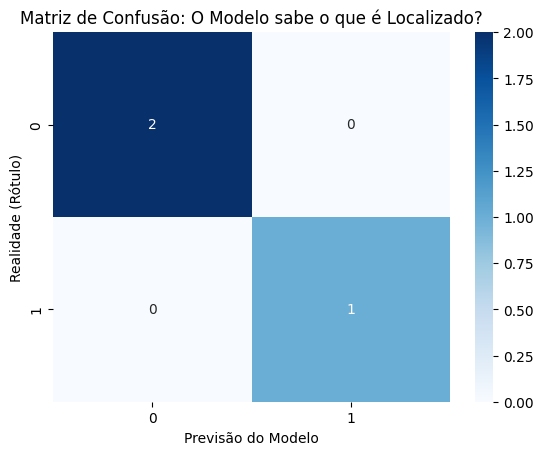

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [150]:
# 1. Fazer previsões nos dados de teste (os 20% reservados)
y_pred_probs = model.predict(X_test_reshaped)

# 2. Converter probabilidades para classes (0 ou 1)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Gerar a Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

# Plotar visualmente
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Realidade (Rótulo)')
plt.title('Matriz de Confusão: O Modelo sabe o que é Localizado?')
plt.show()

print(classification_report(y_test, y_pred))

Predicting the result

In [151]:
df_probs.head()

,prob_0,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,...,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201,prob_202,label
0,0.0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,0.0,0.000140,...,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13,0.0,0
1,0.0,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,0.0,0.000146,...,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13,0.0,0
2,0.0,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,0.0,0.000119,...,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13,0.0,0
3,0.0,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,0.0,0.000170,...,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13,0.0,0
4,0.0,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,0.0,0.000141,...,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13,0.0,0


In [152]:
# Usaremos todos os dados para prever o ponto crítico

df_probs = df_probs.drop(columns=[df_probs.columns[0], df_probs.columns[-2], df_probs.columns[-1]])
df_probs.head()

,prob_1,prob_2,prob_3,prob_4,prob_5,prob_6,prob_7,prob_8,prob_9,prob_10,...,prob_192,prob_193,prob_194,prob_195,prob_196,prob_197,prob_198,prob_199,prob_200,prob_201
0,2.138135e-13,0.0,2.283053e-10,0.0,5.043424e-08,0.0,0.000004,0.0,0.000140,0.0,...,0.0,0.000140,0.0,0.000004,0.0,5.043424e-08,0.0,2.283053e-10,0.0,2.138135e-13
1,2.296157e-13,0.0,2.436389e-10,0.0,5.345898e-08,0.0,0.000004,0.0,0.000146,0.0,...,0.0,0.000146,0.0,0.000004,0.0,5.345898e-08,0.0,2.436389e-10,0.0,2.296157e-13
2,1.693602e-13,0.0,1.838433e-10,0.0,4.131376e-08,0.0,0.000003,0.0,0.000119,0.0,...,0.0,0.000119,0.0,0.000003,0.0,4.131376e-08,0.0,1.838433e-10,0.0,1.693602e-13
3,3.021244e-13,0.0,3.120592e-10,0.0,6.652273e-08,0.0,0.000005,0.0,0.000170,0.0,...,0.0,0.000170,0.0,0.000005,0.0,6.652273e-08,0.0,3.120592e-10,0.0,3.021244e-13
4,2.373574e-13,0.0,2.485749e-10,0.0,5.372293e-08,0.0,0.000004,0.0,0.000141,0.0,...,0.0,0.000141,0.0,0.000004,0.0,5.372293e-08,0.0,2.485749e-10,0.0,2.373574e-13


In [153]:
df_probs_test_reshaped = df_probs.values.reshape(df_probs.shape[0], df_probs.shape[1], 1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 


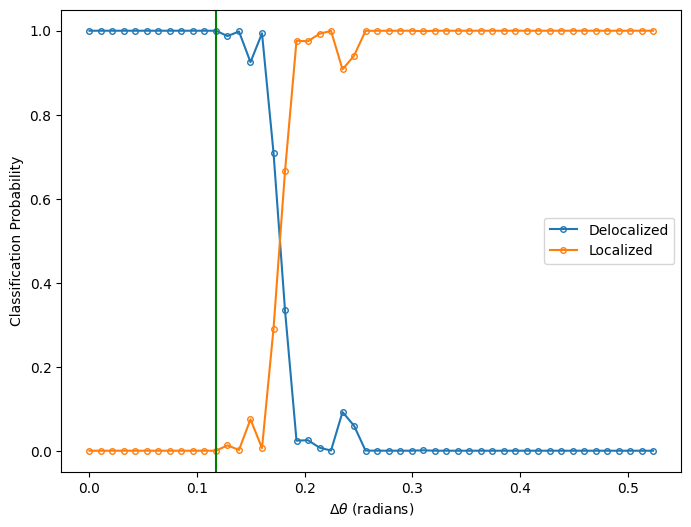

In [154]:
probs = model.predict(df_probs_test_reshaped)

# valores de theta para plotar
delta_theta_trans = df.filter(like='delta_theta').values.flatten()
# Supondo que 'delta_thetas' seja a lista de valores que você usou na transição
prob_delocalized = probs[:, 0]
prob_localized = probs[:, 1]

plt.figure(figsize=(8, 6))
plt.plot(delta_theta_trans, prob_delocalized, '-o', label='Delocalized', markersize=4, markerfacecolor='none')
plt.plot(delta_theta_trans, prob_localized, '-o', label='Localized', markersize=4, markerfacecolor='none')

# Linha vertical no ponto de cruzamento (ajuste o 0.2 para o seu resultado)
plt.axvline(x=critical_exp, color='green', linestyle='-') 
#plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.xlabel(r'$\Delta\theta$ (radians)')
plt.ylabel('Classification Probability')
plt.legend()
plt.show()

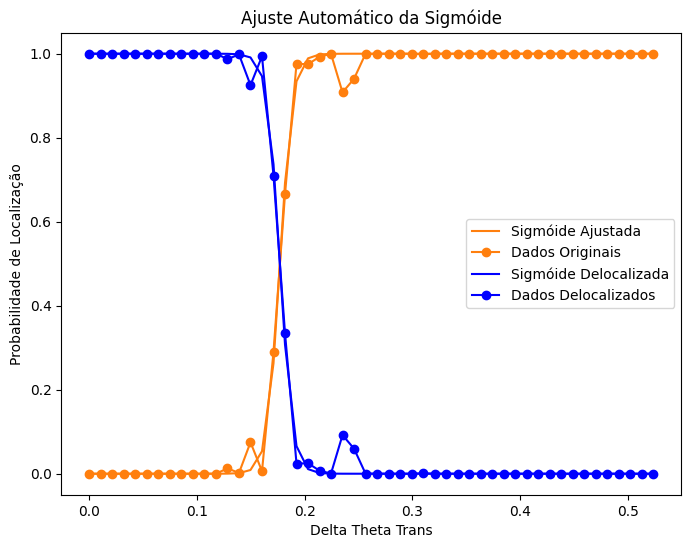

In [155]:
def sigmoide_automatica(x, y):
    # --- AUTO-CHUTE (O segredo para não falhar) ---
    # Centro (x0): Onde o y está mais próximo de 0.5
    x0_chute = x[np.argmin(np.abs(y - 0.5))]
    
    # Inclinação (k): Estimada pela diferença entre os extremos
    # Se a curva sobe, k é positivo. Se desce, k é negativo.
    k_chute = (y[-1] - y[0]) / (x[-1] - x[0]) * 4 

    # Função modelo: Sigmóide padrão
    def f(x, k, x0):
        return 1 / (1 + np.exp(-k * (x - x0)))

    # Ajuste com os chutes calculados automaticamente
    popt, pcov = curve_fit(f, x, y, p0=[k_chute, x0_chute])
    
    return popt # Retorna [k, x0]

# Aplicar a função de ajuste automático
k_ajustado, x0_ajustado = sigmoide_automatica(delta_theta_trans, prob_localized)
prob_localized_ajustada = 1 / (1 + np.exp(-k_ajustado * (delta_theta_trans - x0_ajustado)))

k_ajustado_delocalized = -k_ajustado
x0_ajustado_delocalized = x0_ajustado
prob_delocalized_ajustada = 1 / (1 + np.exp(-k_ajustado_delocalized * (delta_theta_trans - x0_ajustado_delocalized)))
plt.figure(figsize=(8, 6))
plt.plot(delta_theta_trans, prob_localized_ajustada, '-', color='tab:orange', label='Sigmóide Ajustada')
plt.plot(delta_theta_trans, prob_localized, '-o', color='tab:orange', label='Dados Originais')
plt.plot(delta_theta_trans, prob_delocalized_ajustada, '-', color='blue', label='Sigmóide Delocalizada')
plt.plot(delta_theta_trans, prob_delocalized, '-o', color='blue', label='Dados Delocalizados')
plt.xlabel('Delta Theta Trans')
plt.ylabel('Probabilidade de Localização')
plt.title('Ajuste Automático da Sigmóide')
plt.legend()
plt.show()

In [156]:
x0_ajustado,sigmoide_automatica(delta_theta_trans, prob_localized)[1]

(np.float64(0.1769461610766197), np.float64(0.1769461610766197))

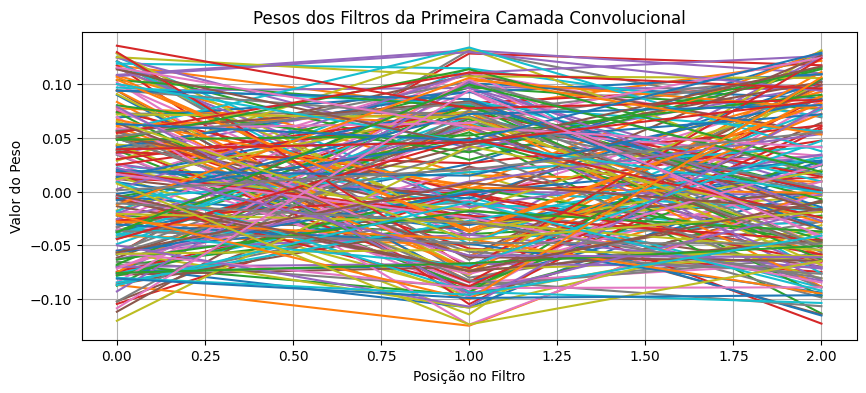

In [157]:
# Pega os pesos da primeira camada Conv1D
pesos_conv1, bias_conv1 = model.layers[0].get_weights()

# Visualiza os pesos do primeiro filtro
plt.figure(figsize=(10, 4))
for i in range(pesos_conv1.shape[2]):
    plt.plot(pesos_conv1[:, 0, i], label=f'Filtro {i+1}')
plt.title('Pesos dos Filtros da Primeira Camada Convolucional')
plt.xlabel('Posição no Filtro')
plt.ylabel('Valor do Peso')
#plt.legend()
plt.grid()
plt.show()

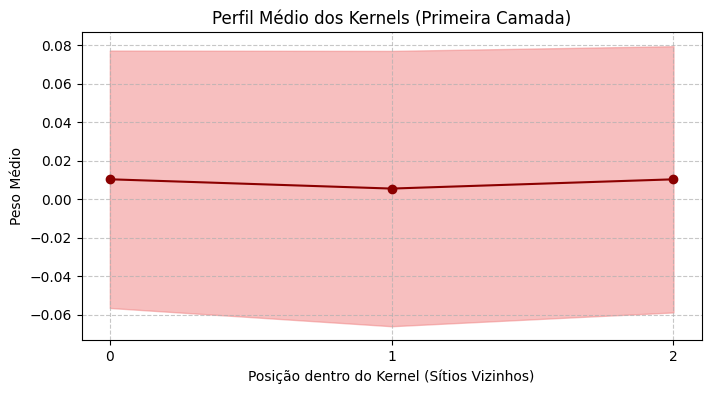

In [158]:
# 1. Acessar os pesos da primeira camada (Conv1D)
# O formato é (kernel_size, input_channels, n_filtros)
pesos, biases = model.layers[0].get_weights()

# 2. Calcular a média entre todos os filtros
# Fazemos a média no eixo 2 (o eixo dos filtros)
media_filtros = np.mean(pesos, axis=2) 
sd_filtros = np.std(pesos, axis=2)

# Como temos apenas 1 canal de entrada, pegamos o índice 0 do canal
media_final = media_filtros[:, 0]
sd_final = sd_filtros[:, 0]
# 3. Plotar o perfil médio aprendido
plt.figure(figsize=(8, 4))
plt.plot(media_final, marker='o', linestyle='-', color='darkred')
plt.fill_between(range(len(media_final)), media_final - sd_final, media_final + sd_final, color='lightcoral', alpha=0.5, label='Desvio Padrão')
plt.title("Perfil Médio dos Kernels (Primeira Camada)")
plt.xlabel("Posição dentro do Kernel (Sítios Vizinhos)")
plt.ylabel("Peso Médio")
plt.xticks(range(len(media_final))) # Mostra 0, 1, 2 (se o kernel for 3)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


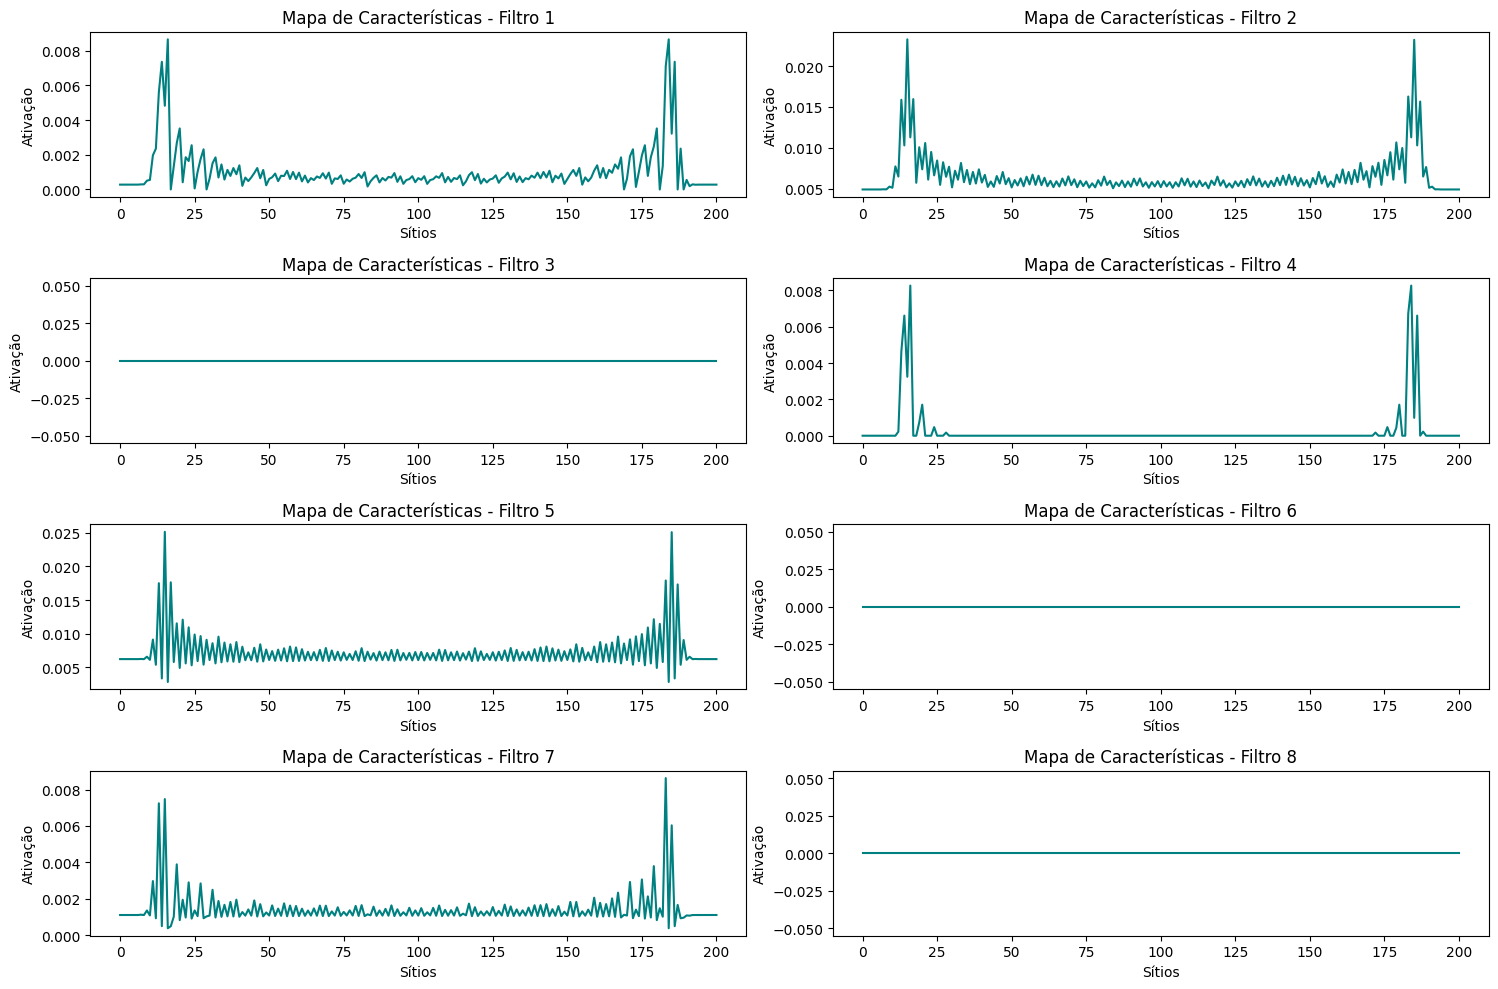

In [160]:
# 1. Pegar a saída da primeira camada
first_layer_output = model.layers[0].output

# 2. Em vez de model.input, vamos usar explicitamente a estrutura do Sequential
# Isso resolve o erro de "layer has never been called"
activation_model = models.Model(inputs=model.inputs, outputs=first_layer_output)

# 3. Escolher a amostra (ex: a primeira do seu teste)
amostra = X_test_reshaped[0:1]

# 4. Predizer os mapas
feature_maps = activation_model.predict(amostra)

# 4. Plotar alguns dos mapas de características
# Vamos plotar os primeiros 8 filtros para comparar
n_filtros_plot = 8
plt.figure(figsize=(15, 10))

for i in range(n_filtros_plot):
    plt.subplot(4, 2, i + 1)
    # O mapa tem shape (1, n_sitios, n_filtros)
    plt.plot(feature_maps[0, :, i], color='teal')
    plt.title(f'Mapa de Características - Filtro {i+1}')
    plt.xlabel('Sítios')
    plt.ylabel('Ativação')

plt.tight_layout()
plt.show()

# Saving model

In [ ]:
# Definir o nome do arquivo
#filename = 'modelo_svm_qw_final.joblib'

# Salvar o modelo e também o scaler (se você usou um)
#joblib.dump(clf3, f'data/{filename}')

# Se você usou normalização, SALVE o scaler também! 
# Você precisará dele para tratar os dados novos do mesmo jeito
# joblib.dump(scaler, 'scaler_qw.joblib')

#print(f"Modelo salvo com sucesso em: {filename}")